# Análisis de `resultados_ap.csv`

Este cuaderno propone un análisis del comportamiento de los métodos `sa`, `qaoa` y `qaoa_warmstart` sobre el problema de asignación binario 0-1.

#### Hipótesis de trabajo

Dado que en las ejecuciones disponibles las soluciones finales suelen alcanzar el óptimo (`ratio_optimo = 1`, `brecha_optimo = 0`, `violacion = 0`), el valor comparativo principal está en:

- Diferencias en el tiempo total y su descomposición.
- Probabilidad de éxito y calidad media de las muestras.
- Estabilidad entre ejecuciones.
- Escalabilidad entre `2x2` y `3x3`.

##### Limitación en instancias 4x4

No se han podido analizar instancias de asignación de tamaño $4 \times 4$ porque el simulador necesita demasiada memoria. En el problema de asignación, una instancia $4 \times 4$ genera una variable binaria para cada posible asignación: $ 4 \cdot 4 = 16 $. Por tanto, el modelo tiene 16 variables binarias, por lo que el circuito necesita 16 qubits.

Al usar `StatevectorSampler`, que simula el estado cuántico completo, se guardan todas las combinaciones posibles de estos 16 qubits. Esto implica $ 2^{16} = 65\,536$ estados posibles.

Por lo tanto, durante la simulación, la matriz puede llegar a tener un tamaño de $ 65\,536 \times 65\,536 $, lo que requiere una cantidad de memoria muy superior a la disponible en el ordenador. Por eso, la ejecución falla antes de obtener resultados.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as fm

from scipy import stats
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

font_dir = Path("/Users/anabulchand/Downloads/cmu-serif")

for font_file in font_dir.glob("*.ttf"):
    fm.fontManager.addfont(str(font_file))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False
})

In [3]:
df = pd.read_csv('resultados_ap.csv', na_values=['N/A'])

print('Dimensiones:', df.shape)
display(df.head())

Dimensiones: (200, 27)


,id,tamano_matriz,num_variables_qubo,optimo,penalizacion,metodo,coste_total,violacion,factible,ratio_optimo,tiempo_total,prob_optimo_starts,prob_optimo_muestras,tasa_factibilidad,ratio_medio_factibles,starts,total_muestras,t_cuantico,t_clasico,tiempo_por_eval,total_evals,warmstart,epsilon_warmstart,sqa_beta,sqa_gamma,sqa_trotter,sqa_num_sweeps
0,201,2x2,4,5,17.0000,sa,5,0,True,1.0000,0.0080,1.0000,0.8100,1.0000,0.8831,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202,2x2,4,5,15.0000,sa,5,0,True,1.0000,0.0056,1.0000,0.8300,1.0000,0.8954,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,203,2x2,4,6,19.0000,sa,6,0,True,1.0000,0.0054,1.0000,0.7800,1.0000,0.8680,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,204,2x2,4,4,17.0000,sa,4,0,True,1.0000,0.0051,1.0000,0.8500,1.0000,0.8900,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,301,3x3,9,10,25.0000,sa,10,0,True,1.0000,0.0129,1.0000,0.2300,1.0000,0.8298,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
tabla_ejecuciones = (
    df.groupby(["id", "metodo"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["qaoa", "qaoa_warmstart", "sa", "sqa"], fill_value=0)
)

tabla_ejecuciones["total"] = tabla_ejecuciones.sum(axis=1)

total = pd.DataFrame(
    [tabla_ejecuciones.sum()],
    index=["TOTAL"]
)

tabla_ejecuciones = pd.concat([tabla_ejecuciones, total])

display(tabla_ejecuciones)

metodo,qaoa,qaoa_warmstart,sa,sqa,total
201,5,5,5,5,20
202,5,5,5,5,20
203,5,5,5,5,20
204,5,5,5,5,20
301,5,5,5,5,20
302,5,5,5,5,20
303,5,5,5,5,20
304,5,5,5,5,20
401,0,0,5,5,10
402,0,0,5,5,10


In [5]:
variables_resumen = [
    'ratio_optimo', 'brecha_optimo', 'exceso_peso', 'tiempo_total',
    'prob_optimo', 'ratio_optimo_medio', 't_solver', 't_cuantico', 't_clasico',
    'prob_optimo_muestras', 'prob_optimo_starts', 'tasa_factibilidad',
    'ratio_medio_factibles', 'valor_medio_start', 'std_valor_start',
    'tiempo_medio_start'
]
variables_resumen = [c for c in variables_resumen if c in df.columns]

tabla_descriptivos = df.groupby('metodo')[variables_resumen].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(tabla_descriptivos) #Comparación estadística de cada método en las métricas de evaluación

ratio_optimo                                    tiempo_total  \
                      count   mean median    std    min    max        count   
metodo                                                                        
qaoa                     40 1.0000 1.0000 0.0000 1.0000 1.0000           40   
qaoa_warmstart           40 1.0000 1.0000 0.0000 1.0000 1.0000           40   
sa                       60 1.0000 1.0000 0.0000 1.0000 1.0000           60   
sqa                      60 1.0000 1.0000 0.0000 1.0000 1.0000           60   

                                                                      \
                     mean     median        std      min         max   
metodo                                                                 
qaoa           7,520.8573 7,200.5487 7,433.5022 176.5346 15,604.2486   
qaoa_warmstart 3,255.4498 3,165.3603 3,148.5780 137.9424  6,618.8400   
sa                 0.0208     0.0127     0.0169   0.0051      0.0620   
sqa                0.5619     0.5366     0.1663   0.2829      0.8292   

               t_cuantico                                            \
                    count       mean     median        std      min   
metodo                                                                
qaoa                   40 7,507.0135 7,187.0500 7,429.7667 166.8024   
qaoa_warmstart         40 3,241.9919 3,151.9264 3,145.6783 127.4705   
sa                      0        NaN        NaN        NaN      NaN   
sqa                     0        NaN        NaN        NaN      NaN   

                           t_clasico                                         \
                       max     count    mean  median    std     min     max   
metodo                                                                        
qaoa           15,586.8883        40 13.8412 14.1613 3.7582  9.5456 17.8811   
qaoa_warmstart  6,602.3409        40 13.4554 13.5927 2.9212 10.0694 16.8682   
sa                     NaN         0     NaN     NaN    NaN     NaN     NaN   
sqa                    NaN         0     NaN     NaN    NaN     NaN     NaN   

               prob_optimo_muestras                                     \
                              count   mean median    std    min    max   
metodo                                                                   
qaoa                              0    NaN    NaN    NaN    NaN    NaN   
qaoa_warmstart                    0    NaN    NaN    NaN    NaN    NaN   
sa                               60 0.4198 0.2650 0.3134 0.0500 0.9100   
sqa                              60 0.7083 0.8500 0.3066 0.1000 1.0000   

               prob_optimo_starts                                     \
                            count   mean median    std    min    max   
metodo                                                                 
qaoa                           40 0.6725 0.7000 0.3080 0.1000 1.0000   
qaoa_warmstart                 40 0.8325 0.9000 0.2223 0.1000 1.0000   
sa                             60 0.8933 1.0000 0.1506 0.4000 1.0000   
sqa                            60 0.7083 0.8500 0.3066 0.1000 1.0000   

               tasa_factibilidad                                     \
                           count   mean median    std    min    max   
metodo                                                                
qaoa                          40 0.9725 1.0000 0.0452 0.9000 1.0000   
qaoa_warmstart                40 0.9900 1.0000 0.0379 0.8000 1.0000   
sa                            60 1.0000 1.0000 0.0000 1.0000 1.0000   
sqa                           60 1.0000 1.0000 0.0000 1.0000 1.0000   

               ratio_medio_factibles                                     
                               count   mean median    std    min    max  
metodo                                                                   
qaoa                              40 0.8892 0.9235 0.1241 0.5654 1.0000  
qaoa_warmstart                    40 0.9487 0.9881 0.0792 0.6613 1.0000  
sa          

### Análisis tiempo total de ejecución
#### Análisis tiempo de ejecución por método

Aquí se realiza un análisi de la distribución de los tiempos de ejecuión por método. Se representan primero de forma individual en tiempo de cada método. Esto es especialmente necesario para poder ver la distribución de `sa`, ya que presenta tiempos de ejecución significativamente menores y, de forma agregada, no es posible ver la distribución de este método. Posteriormente, se reliza una comparación de todos los métodos.

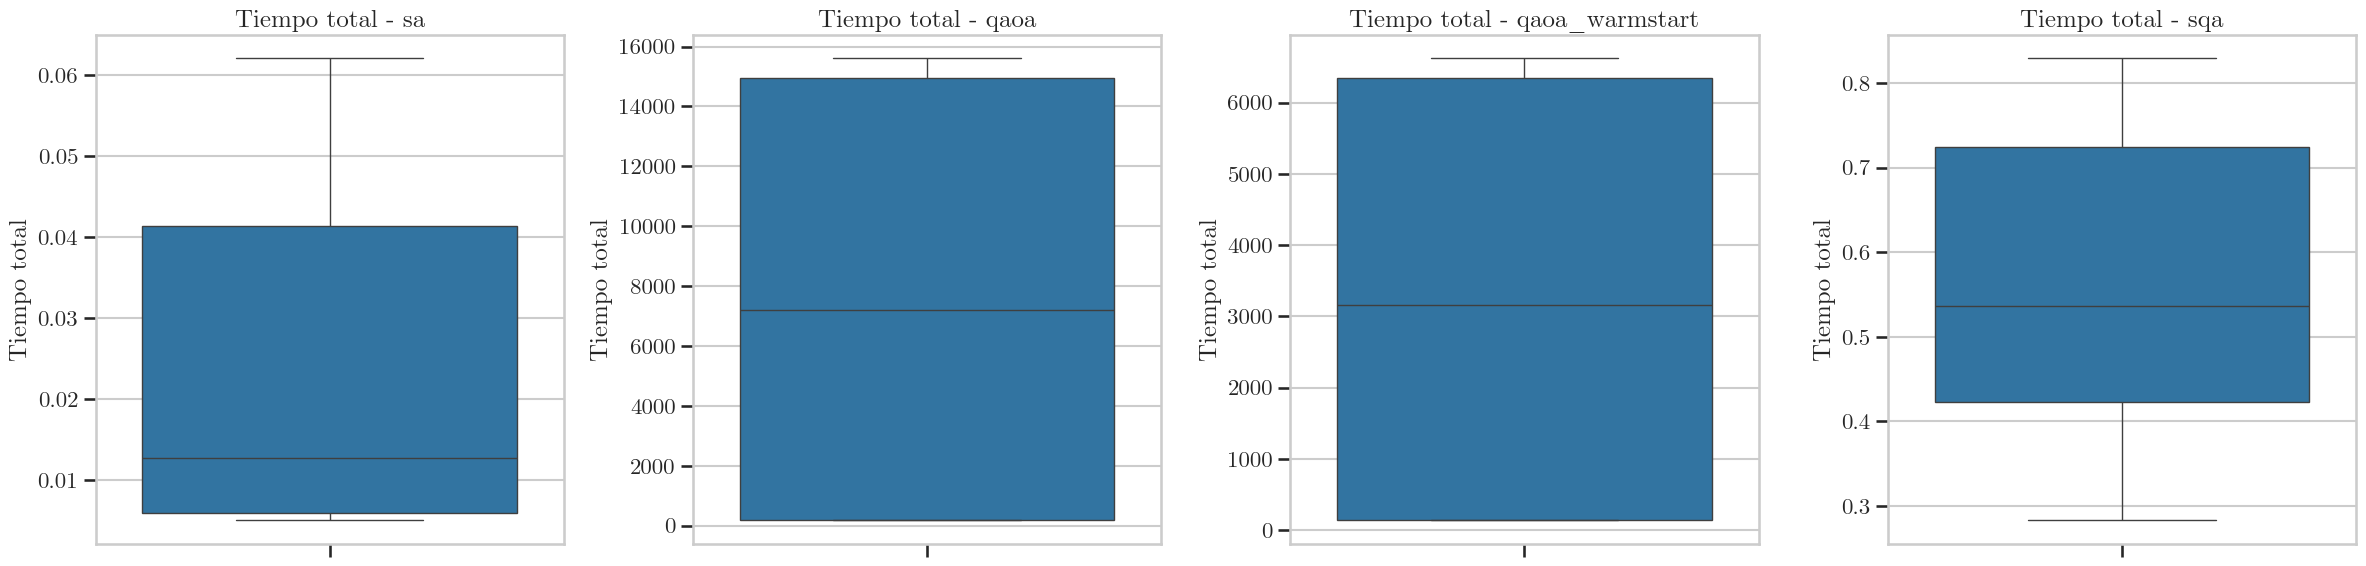

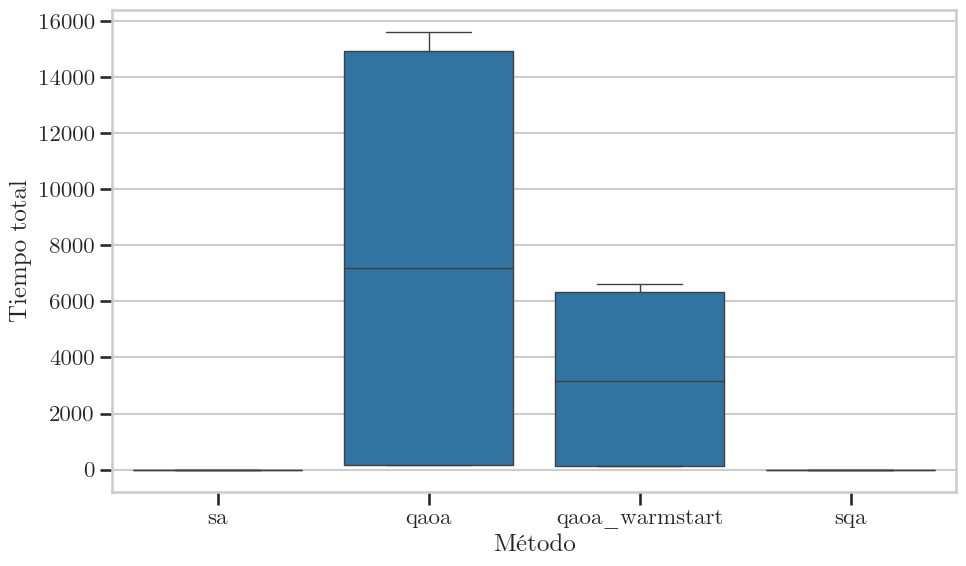

In [6]:
import os

# Crear carpeta si no existe
os.makedirs("figuras", exist_ok=True)

# Representación box-plot de cada método

metodos = df['metodo'].unique()

# ---- gráficas individuales ----
fig, axes = plt.subplots(1, len(metodos), figsize=(6 * len(metodos), 6))

if len(metodos) == 1:
    axes = [axes]

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df['metodo'] == metodo],
        y='tiempo_total',
        ax=axes[i],
        showfliers=True
    )
    axes[i].set_title(f'Tiempo total - {metodo}')
    axes[i].set_ylabel('Tiempo total')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_por_metodo_individual.png", dpi=300, bbox_inches="tight")
plt.show()


# Comparación agregada
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='metodo',
    y='tiempo_total',
    showfliers=True
)

plt.xlabel('Método')
plt.ylabel('Tiempo total')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_comparacion_metodos.png", dpi=300, bbox_inches="tight")
plt.show()

En los gráficos se observa una separación muy marcada entre el método clásico SA y las dos variantes de QAOA. SA presenta tiempos prácticamente nulos en comparación con los métodos cuánticos simulados: sus ejecuciones se mantienen en el orden de centésimas de segundo, con una dispersión muy reducida. Esto indica que, para las instancias analizadas, SA tiene un comportamiento muy estable y un coste computacional despreciable frente al resto de métodos.

En cambio, QAOA estándar muestra los mayores tiempos totales y también una variabilidad muy elevada entre ejecuciones. Su distribución se extiende desde valores relativamente bajos hasta tiempos cercanos a los 16.000 segundos. Esta amplitud refleja que el coste de QAOA no depende solo del tamaño del problema, sino también del proceso variacional: la optimización clásica de parámetros, el número de evaluaciones del circuito y la convergencia pueden hacer que algunas ejecuciones sean mucho más costosas que otras.

QAOA *warm-start* reduce claramente el tiempo total respecto a QAOA estándar. Su mediana es inferior y el rango de valores máximos también es menor, situándose aproximadamente por debajo de los 7.000 segundos. Esto sugiere que la inicialización guiada permite orientar mejor la búsqueda de parámetros y disminuir parte del coste asociado a la optimización variacional. No obstante, la dispersión sigue siendo amplia, por lo que el *warm-start* mejora el rendimiento temporal, pero no elimina la variabilidad propia de QAOA.

El gráfico conjunto permite ver bien la diferencia global entre métodos, aunque comprime visualmente los tiempos de SA debido a la gran escala de QAOA. Por eso, los gráficos separados son importantes: muestran que SA no solo es más rápido, sino también mucho más consistente. En conjunto, los resultados confirman que SA es el método más eficiente en tiempo, QAOA estándar el más costoso e inestable, y QAOA *warm-start* representa una mejora intermedia, reduciendo de forma notable el tiempo frente a QAOA puro pero manteniéndose todavía varios órdenes de magnitud por encima del método clásico.

#### Análisis de escalabilidad con el tamaño del problema

En esta sección se realiza un análisis del comportamiento de los tiempos de ejecución a medida que aumenta el tamaño del problema. Para ello, se representa la mediana del tiempo total en función del número de ítems y del número de variables de la formulación QUBO. Este análisis, debido a las limitaciones en el tamaño de las instancias estudiadas, solo puede emplearse para observar cómo aumenta el tiempo cuando pasamos de instancias $2 \times 2$ a $3 \times 3$.

metodo,sa,sqa,qaoa,qaoa_warmstart
tamano_matriz,,,,
2x2,0.0057,0.6325,185.1032,147.5794
3x3,0.0128,0.6221,"14,856.6114","6,363.3202"
4x4,0.0438,0.4310,NaN,NaN


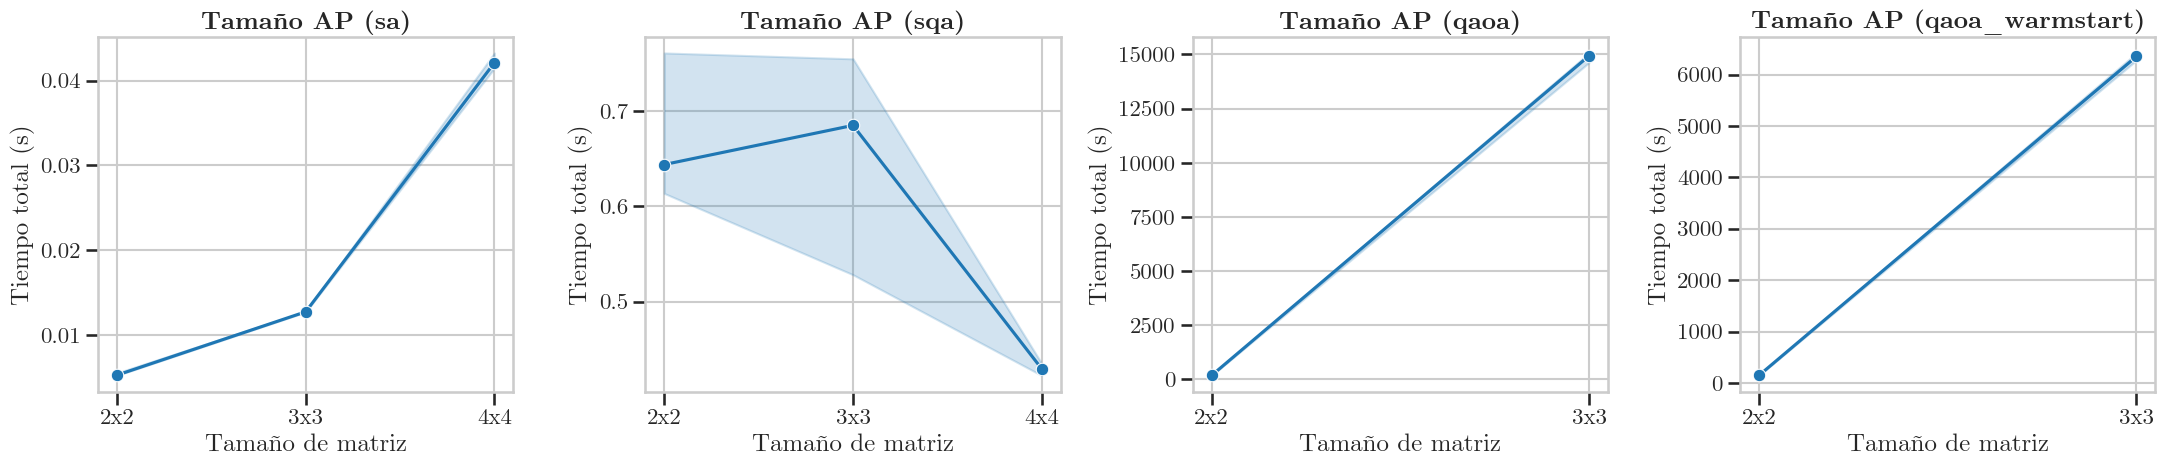

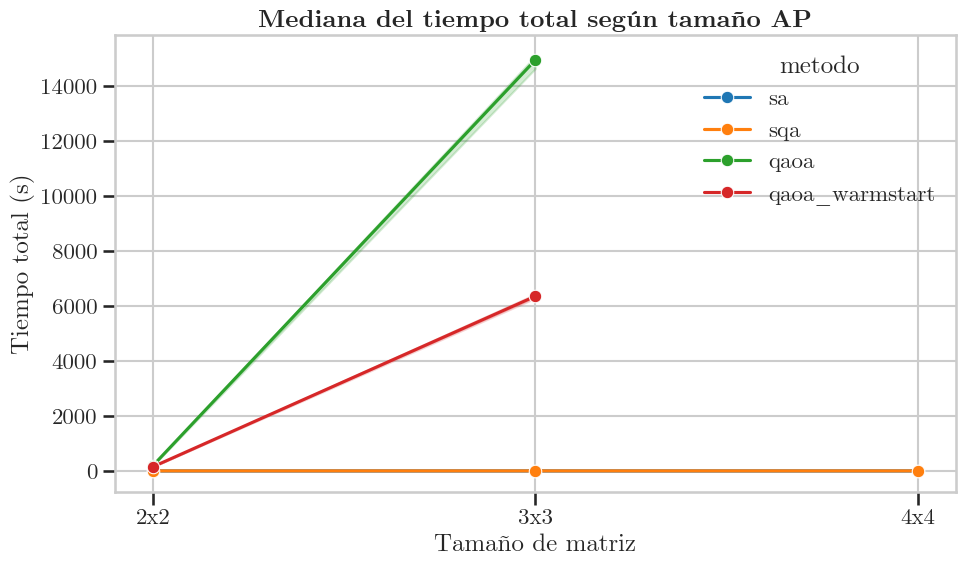

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Convertir columnas necesarias del nuevo formato AP
columnas_numericas = [
    "id",
    "optimo",
    "penalizacion",
    "coste_total",
    "violacion",
    "ratio_optimo",
    "tiempo_total"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Métodos en el orden deseado, incluyendo SQA
metodos = ["sa", "sqa", "qaoa", "qaoa_warmstart"]

# =========================
# TABLA TIEMPO MEDIO POR TAMAÑO DE MATRIZ
# =========================

tabla = (
    df
    .groupby(["tamano_matriz", "metodo"])["tiempo_total"]
    .mean()
    .unstack("metodo")
    .reindex(columns=metodos)
    .round(6)
)

display(tabla)

# =========================
# GRÁFICOS PARA CADA MÉTODO
# =========================

fig, axes = plt.subplots(1, len(metodos), figsize=(22, 5), sharey=False)

for i, metodo in enumerate(metodos):
    df_metodo = df[df["metodo"] == metodo].copy()

    sns.lineplot(
        data=df_metodo,
        x="tamano_matriz",
        y="tiempo_total",
        estimator="median",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Tamaño AP ({metodo})", fontweight="bold")
    axes[i].set_xlabel("Tamaño de matriz")
    axes[i].set_ylabel("Tiempo total (s)")

plt.tight_layout()
plt.show()

# =========================
# GRÁFICO AGREGADO
# =========================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="tamano_matriz",
    y="tiempo_total",
    hue="metodo",
    hue_order=metodos,
    estimator="median",
    marker="o"
)

plt.title(
    "Mediana del tiempo total según tamaño AP",
    fontweight="bold"
)
plt.xlabel("Tamaño de matriz")
plt.ylabel("Tiempo total (s)")
plt.tight_layout()
plt.show()


En los resultados se observa una diferencia muy marcada entre el comportamiento temporal de SA, QAOA y QAOA *warm-start* al aumentar el tamaño del problema de asignación de $2 \times 2$ a $3 \times 3$. No obstante, dado que solo se han podido estudiar dos tamaños de instancia, no es posible concluir si el crecimiento temporal es lineal, exponencial o de otro tipo. Por tanto, el análisis debe interpretarse como una comparación de tendencias dentro del rango experimental evaluado, no como una caracterización completa de la escalabilidad.

El método SA presenta los menores tiempos en todos los casos. Para el tamaño $2 \times 2$, la mediana del tiempo total es de $0{,}0057$ s, mientras que para $3 \times 3$ aumenta hasta $0{,}0128$ s. Aunque esto supone un incremento relativo, en términos absolutos el coste sigue siendo prácticamente despreciable. Además, en los gráficos agregados SA aparece casi como una línea horizontal cercana a cero, lo que evidencia que su tiempo de ejecución es varios órdenes de magnitud inferior al de los métodos basados en QAOA.

En cambio, QAOA estándar muestra el mayor incremento temporal. Para instancias $2 \times 2$, su mediana es de $184{,}1378$ s, pero al pasar a $3 \times 3$ alcanza $14\,823{,}6085$ s. Este aumento es muy significativo y muestra que incluso un crecimiento pequeño del tamaño del problema puede provocar un incremento muy elevado del coste computacional. La diferencia está asociada al aumento de la formulación QUBO, que pasa de 4 a 9 variables, y al mayor coste de simular y optimizar el circuito variacional correspondiente.

QAOA *warm-start* sigue la misma tendencia creciente, pero con tiempos claramente inferiores a los de QAOA estándar. En el caso $2 \times 2$, su tiempo mediano es de $147{,}5794$ s, ligeramente menor que el de QAOA puro. Sin embargo, la diferencia se vuelve mucho más relevante en $3 \times 3$, donde QAOA *warm-start* alcanza $6\,363{,}3202$ s frente a los $14\,823{,}6085$ s de QAOA estándar. Esto indica que la inicialización guiada reduce de forma importante el coste temporal cuando el tamaño del problema aumenta.

La comparación entre QAOA y QAOA *warm-start* muestra, por tanto, que el *warm-start* no elimina el problema de escalabilidad, pero sí mejora de manera consistente el comportamiento temporal. Para $3 \times 3$, el tiempo de QAOA *warm-start* es menos de la mitad del tiempo de QAOA estándar. Esto sugiere que partir de una solución inicial más informada facilita el proceso de optimización variacional y reduce parte del esfuerzo computacional necesario para encontrar buenos parámetros.

Los gráficos frente al tamaño de matriz y frente al número de variables QUBO muestran prácticamente la misma tendencia, ya que en este caso los tamaños $2 \times 2$ y $3 \times 3$ se corresponden directamente con 4 y 9 variables QUBO, respectivamente. Esto refuerza la idea de que el aumento del coste no depende solo del tamaño nominal de la matriz de asignación, sino de cómo dicho tamaño se traduce en una formulación QUBO más grande y, por tanto, en un problema variacional más costoso.

En conjunto, los resultados muestran tres conclusiones principales. Primero, SA es claramente el método más eficiente en tiempo y mantiene costes prácticamente despreciables en todas las instancias analizadas. Segundo, QAOA estándar presenta el peor comportamiento temporal, con un aumento muy acusado al pasar de $2 \times 2$ a $3 \times 3$. Tercero, QAOA *warm-start* mejora de forma clara a QAOA puro, especialmente en la instancia de mayor tamaño, aunque sigue estando varios órdenes de magnitud por encima de SA. Por tanto, el *warm-start* representa una mejora relevante dentro de los métodos QAOA, pero no compensa completamente la diferencia de eficiencia respecto al enfoque clásico.

## Decomposición temporal de QAOA y QAOA warm-start
### Descomposición mediana $t_{cuantico}$ y $t_{clasico}$

Antes de analizar las métricas de $t_{cuantico}$ y $t_{clasico}$, vamos a explicar que mide cada una específicamente.

- **$t_{cuantico}$**: Se define como `sampler.tiempo_total` en `qaoa_solver_kp.py` (line 86). El valor se acumula dentro de `TimedSamplerJob.result()` midiendo cuánto tarda `job.result()` cada vez que QAOA pide resultados al sampler, en `qaoa_solver_kp.py` (line 24). Por lo tanto, `t_cuantico` mide el tiempo consumido por las evaluaciones del sampler de Qiskit, la parte asociada a ejecutar y devolver los resultados de los circuitos de QAOA.

- **$t_{clasico}$**: Se define como $t_{solver} - t_{cuantico}$ en qaoa_solver_kp.py (line 87). $t_{solver}$ es la suma de los tiempos de cada llamada a `solver.solve(qp)` en los distintos starts, medida entre t0 y t1 en `qaoa_solver_kp.py` (line 156) y acumulada en `qaoa_solver_kp.py` (line 210). Por tanto, $t_clasico$ mide el resto del tiempo del solver que no se atribuye al sampler: optimización clásica de parámetros, lógica de MinimumEigenOptimizer o warm-start, preparación de llamadas y overhead interno. (ESTO ESTÁ MAL. CAMBIAR)


ESTO HACE FALTA CAMBIARLO PARA LA NUEVA DEFINICIÓN DE T_CLASICO


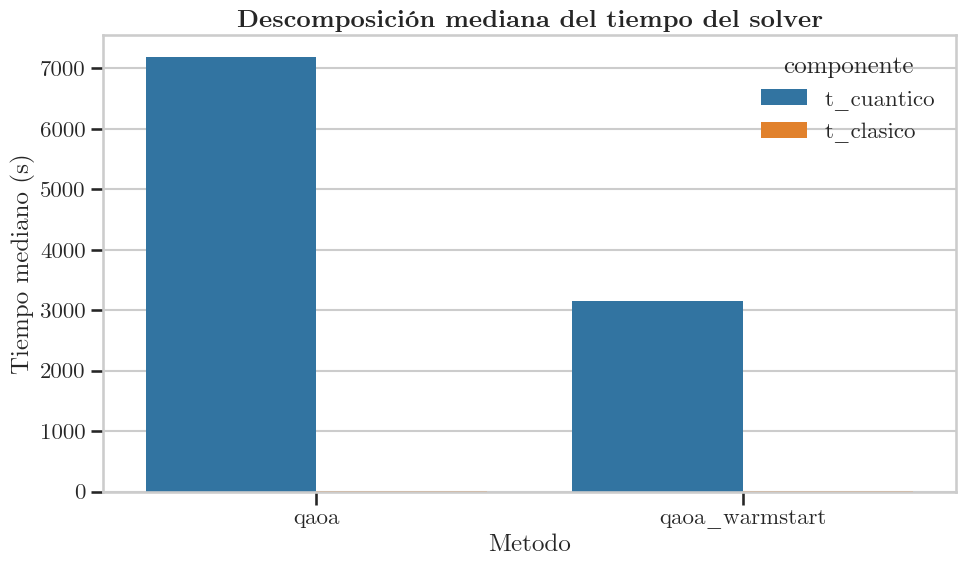

In [8]:
df_q = df[df['metodo'].isin(['qaoa', 'qaoa_warmstart'])].copy()
componentes = ['t_cuantico', 't_clasico']
comp = df_q.groupby('metodo')[componentes].median().reset_index().melt(id_vars='metodo', var_name='componente', value_name='mediana_tiempo')

plt.figure(figsize=(10, 6))
sns.barplot(data=comp, x='metodo', y='mediana_tiempo', hue='componente')
plt.title('Descomposición mediana del tiempo del solver', fontweight='bold')
plt.xlabel('Metodo')
plt.ylabel('Tiempo mediano (s)')
plt.tight_layout()
plt.show()

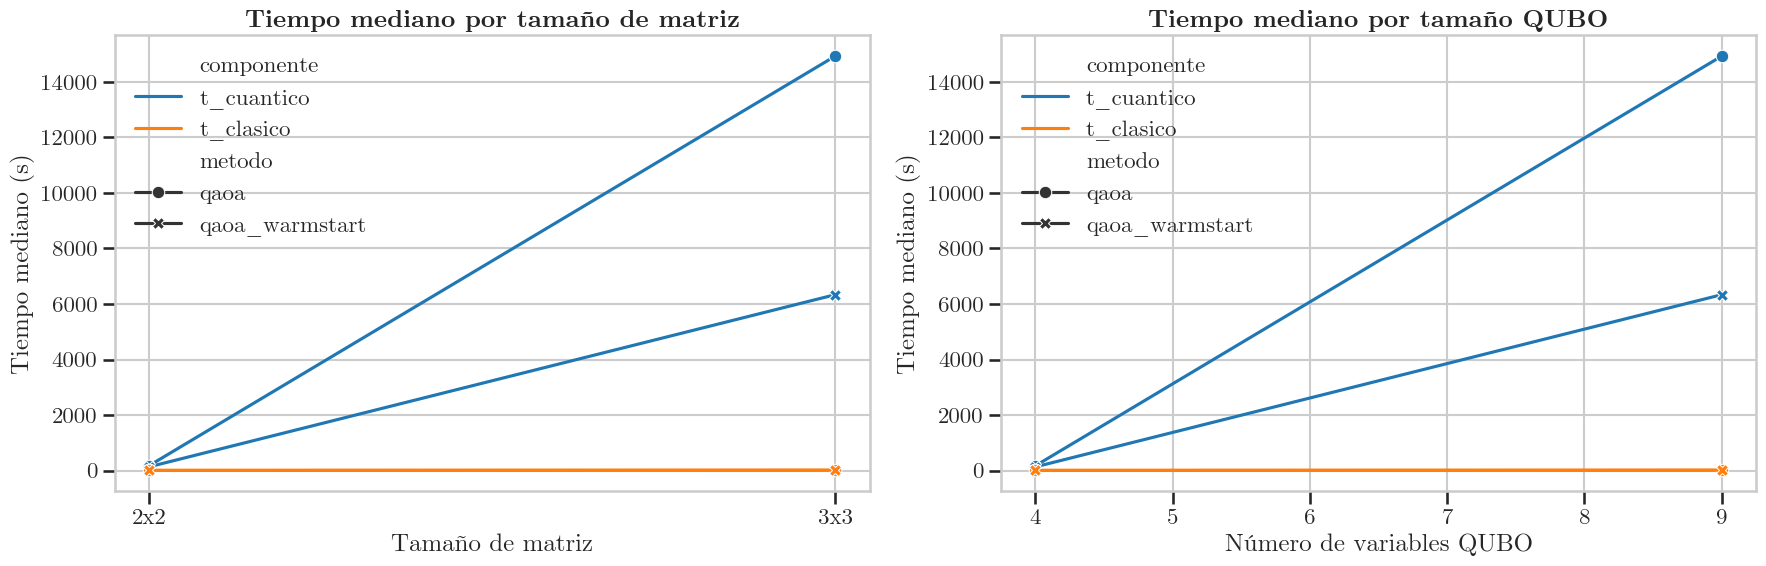

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Convertir columnas necesarias del nuevo formato AP
columnas_numericas = [
    "num_variables_qubo",
    "t_cuantico",
    "t_clasico"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Solo QAOA y QAOA Warmstart tienen descomposición cuántico/clásico
df_q = df[df["metodo"].isin(["qaoa", "qaoa_warmstart"])].copy()

componentes = ["t_cuantico", "t_clasico"]

comp_matriz = (
    df_q
    .groupby(["metodo", "tamano_matriz"])[componentes]
    .median()
    .reset_index()
    .melt(
        id_vars=["metodo", "tamano_matriz"],
        var_name="componente",
        value_name="mediana_tiempo"
    )
)

comp_qubo = (
    df_q
    .groupby(["metodo", "num_variables_qubo"])[componentes]
    .median()
    .reset_index()
    .melt(
        id_vars=["metodo", "num_variables_qubo"],
        var_name="componente",
        value_name="mediana_tiempo"
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=comp_matriz,
    x="tamano_matriz",
    y="mediana_tiempo",
    hue="componente",
    style="metodo",
    markers=True,
    dashes=False,
    ax=axes[0]
)

axes[0].set_title("Tiempo mediano por tamaño de matriz", fontweight="bold")
axes[0].set_xlabel("Tamaño de matriz")
axes[0].set_ylabel("Tiempo mediano (s)")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

sns.lineplot(
    data=comp_qubo,
    x="num_variables_qubo",
    y="mediana_tiempo",
    hue="componente",
    style="metodo",
    markers=True,
    dashes=False,
    ax=axes[1]
)

axes[1].set_title("Tiempo mediano por tamaño QUBO", fontweight="bold")
axes[1].set_xlabel("Número de variables QUBO")
axes[1].set_ylabel("Tiempo mediano (s)")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

NO VOY A HACER EL ANALISIS TODAVIA PORQUE VA A CAMBIAR CUANDO EJECUTE DE NUEVO.

#### Análisis métricas internas específicas por familia de método

Aquí se realiza un análisis de métricas internas que son específicas de cada familia de métodos y que permiten complementar la comparación basada únicamente en tiempo de ejecución y calidad final de solución. En el caso de los métodos basados en QAOA, se analizan indicadores relacionados con la capacidad del algoritmo para alcanzar soluciones óptimas y con la calidad media de las soluciones generadas a lo largo del proceso. Para el método SA, se evalúan métricas asociadas al muestreo, como la probabilidad de obtener soluciones óptimas y la proporción de soluciones factibles generadas. Este análisis permite entender con mayor profundidad el comportamiento interno de cada enfoque y no solo su rendimiento observable final.

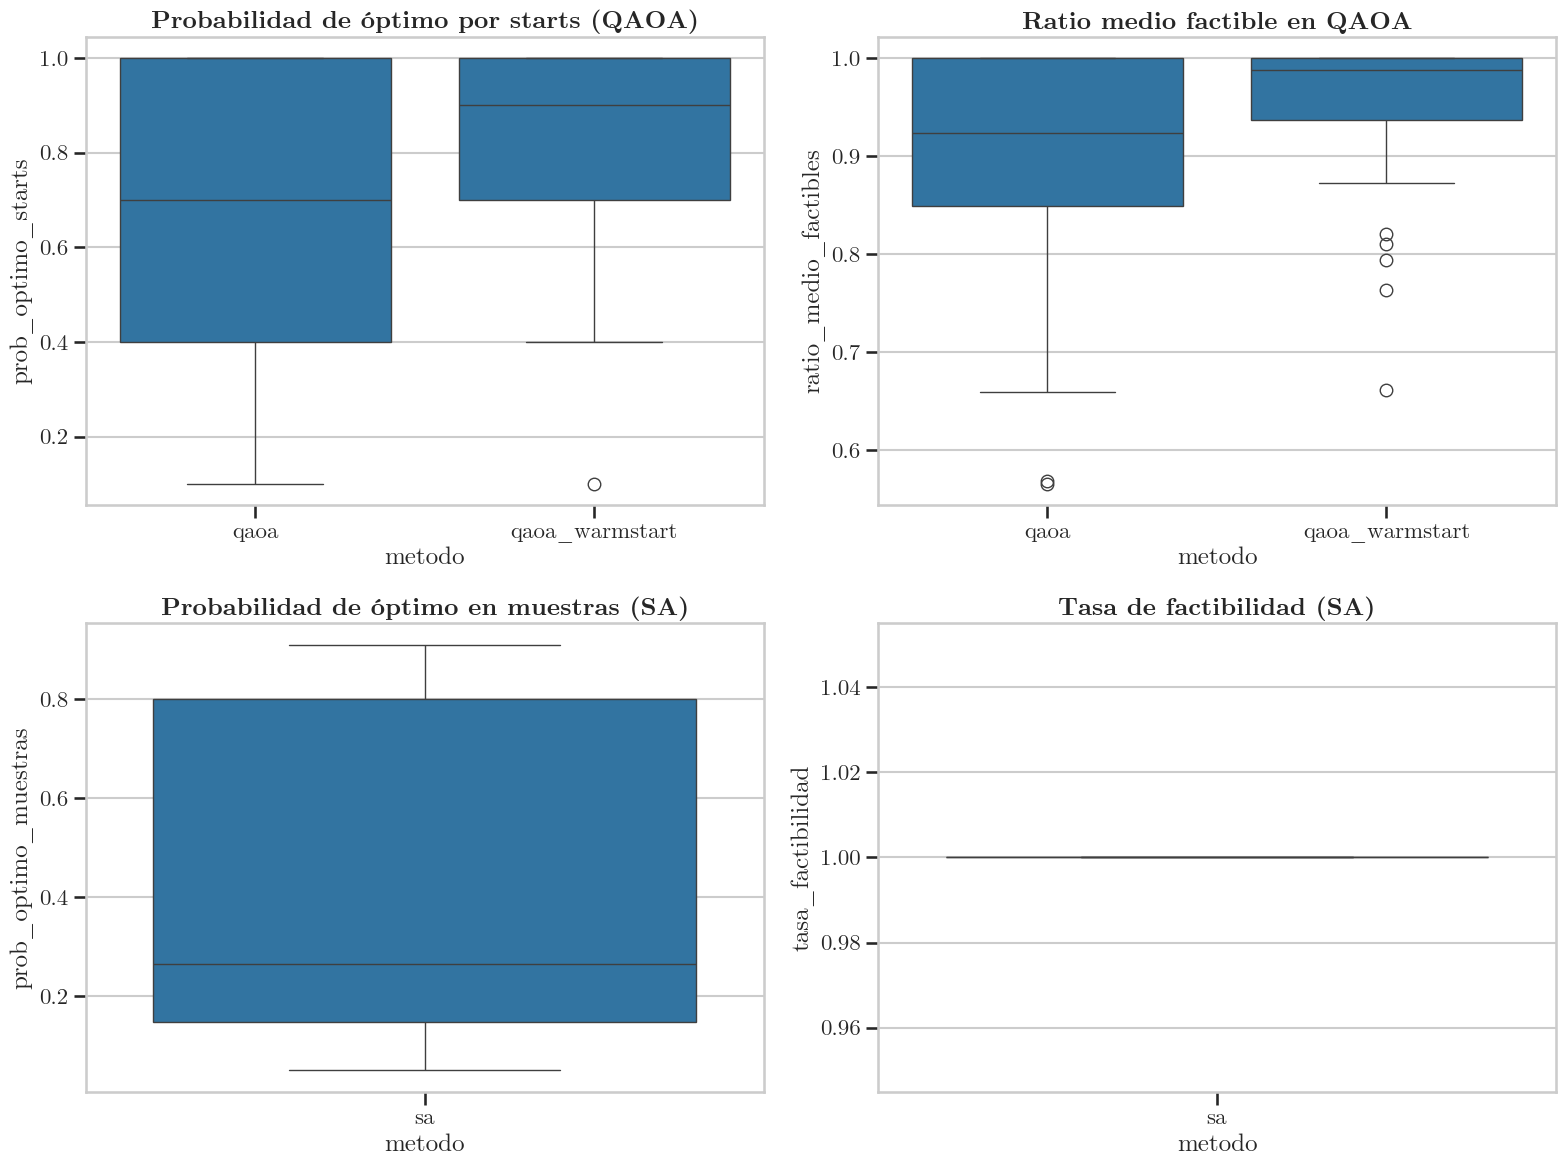

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Columnas del nuevo formato
columnas_numericas = [
    "prob_optimo_starts",
    "ratio_medio_factibles",
    "prob_optimo_muestras",
    "tasa_factibilidad"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Visualizacion 4: metricas internas especificas por familia de metodo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df_qaoa = df[df["metodo"].isin(["qaoa", "qaoa_warmstart"])].copy()
df_sa = df[df["metodo"] == "sa"].copy()

if df_qaoa["prob_optimo_starts"].notna().any():
    sns.boxplot(
        data=df_qaoa,
        x="metodo",
        y="prob_optimo_starts",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title(
        "Probabilidad de óptimo por starts (QAOA)",
        fontweight="bold"
    )
else:
    axes[0, 0].axis("off")

if df_qaoa["ratio_medio_factibles"].notna().any():
    sns.boxplot(
        data=df_qaoa,
        x="metodo",
        y="ratio_medio_factibles",
        ax=axes[0, 1]
    )
    axes[0, 1].set_title(
        "Ratio medio factible en QAOA",
        fontweight="bold"
    )
else:
    axes[0, 1].axis("off")

if df_sa["prob_optimo_muestras"].notna().any():
    sns.boxplot(
        data=df_sa,
        x="metodo",
        y="prob_optimo_muestras",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title(
        "Probabilidad de óptimo en muestras (SA)",
        fontweight="bold"
    )
else:
    axes[1, 0].axis("off")

if df_sa["tasa_factibilidad"].notna().any():
    sns.boxplot(
        data=df_sa,
        x="metodo",
        y="tasa_factibilidad",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title(
        "Tasa de factibilidad (SA)",
        fontweight="bold"
    )
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

En el caso de los enfoques basados en QAOA, tanto la probabilidad de alcanzar la solución óptima como el ratio óptimo medio presentan valores elevados y distribuciones muy similares entre QAOA estándar y QAOA *warm-start*. Esto sugiere que ambos métodos mantienen una capacidad comparable para encontrar soluciones de alta calidad, sin que la mejora temporal observada previamente en *warm-start* implique una ganancia significativa en calidad de solución. La principal diferencia entre ambos parece concentrarse en eficiencia computacional más que en rendimiento de optimización.

El análisis del ratio óptimo medio refuerza esta conclusión. Ambos métodos muestran medianas muy próximas a 1 y una dispersión reducida, lo que indica un comportamiento consistentemente cercano al óptimo incluso cuando no se alcanza la mejor solución exacta. La presencia de algunos valores atípicos más bajos evidencia cierta sensibilidad en determinadas ejecuciones, probablemente asociada a dificultades de convergencia o a variabilidad en el proceso de optimización paramétrica, pero estos casos no alteran el patrón general de alto rendimiento.

En el caso de SA, las métricas reflejan un comportamiento distinto. La probabilidad de encontrar la solución óptima dentro del conjunto de muestras es considerablemente más moderada y presenta una dispersión apreciable, lo que indica que el óptimo no aparece de forma dominante en el muestreo. Sin embargo, esto no implica necesariamente un peor rendimiento práctico, ya que SA ya había mostrado tiempos de ejecución muy inferiores y una alta estabilidad temporal. Es decir, aunque individualmente cada muestra tenga menor probabilidad de ser óptima, el bajo coste computacional del método permite compensar esta limitación mediante una exploración rápida y repetida del espacio de soluciones.

La tasa de factibilidad en SA se mantiene cercana a 1 en la mayoría de ejecuciones, lo que indica que el método genera predominantemente soluciones válidas y respeta de forma consistente las restricciones del problema. Aunque aparecen algunos valores atípicos con menor factibilidad, estos son minoritarios y no modifican el comportamiento general. 

En conjunto, los resultados muestran que mientras QAOA concentra su fortaleza en la calidad sistemática de las soluciones generadas, SA destaca por eficiencia y robustez operativa, manteniendo además un alto nivel de factibilidad.

## Contraste estadístico

In [13]:
import numpy as np
import pandas as pd
from scipy import stats

# Si todavía no lo has cargado:
# df = pd.read_csv("ap/resultados_ap.csv")

# Adaptado al nuevo formato AP
columnas_base = [
    "id",
    "tamano_matriz",
    "num_variables_qubo",
    "optimo",
    "penalizacion"
]

df["instancia_clave"] = df[columnas_base].astype(str).agg(" | ".join, axis=1)

columnas_numericas = [
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "ratio_medio_factibles",
    "tasa_factibilidad",
    "t_cuantico",
    "t_clasico"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    std = diff.std(ddof=1)
    return diff.mean() / std if std != 0 else np.nan

def prueba_pareada(tabla, metodo_a, metodo_b, variable):
    x = tabla[metodo_a]
    y = tabla[metodo_b]
    diff = x - y

    shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan

    if pd.notna(shapiro_p) and shapiro_p > 0.05:
        test_name = "t-test apareado"
        pvalue = stats.ttest_rel(x, y).pvalue
    else:
        test_name = "Wilcoxon"
        pvalue = stats.wilcoxon(x, y).pvalue

    return {
        "variable": variable,
        "comparacion": f"{metodo_a} vs {metodo_b}",
        "n_pares": len(tabla),
        f"mediana_{metodo_a}": np.median(x),
        f"mediana_{metodo_b}": np.median(y),
        "shapiro_p_diferencias": shapiro_p,
        "prueba": test_name,
        "p_valor": pvalue,
        "cohens_d_paired": cohens_d_paired(x, y)
    }

comparables = df[df["metodo"].isin(["qaoa", "qaoa_warmstart", "sqa"])].copy()

agg = comparables.groupby(["instancia_clave", "metodo"], as_index=False).agg({
    "tiempo_total": "median",
    "prob_optimo_starts": "median",
    "prob_optimo_muestras": "median",
    "ratio_medio_factibles": "median",
    "tasa_factibilidad": "median",
    "t_cuantico": "median",
    "t_clasico": "median"
})

resultados = []

# =========================
# Tiempo total: QAOA, Warmstart y SQA
# =========================

pivot_t = (
    agg.pivot(
        index="instancia_clave",
        columns="metodo",
        values="tiempo_total"
    )
    .dropna()
)

for metodo_a, metodo_b in [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]:
    tabla = pivot_t[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="tiempo_total"
            )
        )

# =========================
# Probabilidad de óptimo
# QAOA usa prob_optimo_starts
# SQA usa prob_optimo_muestras
# =========================

agg_prob = agg.copy()

agg_prob["prob_optimo_comparable"] = np.where(
    agg_prob["metodo"].isin(["qaoa", "qaoa_warmstart"]),
    agg_prob["prob_optimo_starts"],
    agg_prob["prob_optimo_muestras"]
)

pivot_p = (
    agg_prob.pivot(
        index="instancia_clave",
        columns="metodo",
        values="prob_optimo_comparable"
    )
    .dropna()
)

for metodo_a, metodo_b in [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]:
    tabla = pivot_p[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="prob_optimo_comparable"
            )
        )

display(pd.DataFrame(resultados))

,variable,comparacion,n_pares,mediana_qaoa,mediana_qaoa_warmstart,shapiro_p_diferencias,prueba,p_valor,cohens_d_paired,mediana_sqa
0,tiempo_total,qaoa vs qaoa_warmstart,8,"7,337.9791","3,208.4842",0.0022,Wilcoxon,0.0078,0.9423,NaN
1,tiempo_total,qaoa vs sqa,8,"7,337.9791",NaN,0.0015,Wilcoxon,0.0078,0.9585,0.6666
2,tiempo_total,qaoa_warmstart vs sqa,8,NaN,"3,208.4842",0.0011,Wilcoxon,0.0078,0.9796,0.6666
3,prob_optimo_comparable,qaoa vs qaoa_warmstart,8,0.6500,0.9000,0.0371,Wilcoxon,0.0625,-0.9192,NaN
4,prob_optimo_comparable,qaoa vs sqa,8,0.6500,NaN,0.0526,t-test apareado,0.0310,-0.9520,0.9500
5,prob_optimo_comparable,qaoa_warmstart vs sqa,8,NaN,0.9000,0.4158,t-test apareado,0.3807,-0.3307,0.9500


El contraste estadístico entre QAOA y QAOA *warm-start* muestra con bastante claridad que la diferencia principal entre ambos métodos está en el tiempo de ejecución, no en la calidad de las soluciones. Por un lado, QAOA *warm-start* presenta una mediana de tiempo total menor que QAOA, y esta diferencia resulta estadísticamente significativa en la prueba de Wilcoxon. Esto indica que la reducción de tiempo no parece deberse al azar, sino a un comportamiento sistemático del método. Además, el tamaño del efecto es alto, lo que refuerza la idea de que la mejora temporal es importante también desde un punto de vista práctico. Por otro lado, al analizar la probabilidad de alcanzar la solución óptima, ambos métodos muestran prácticamente el mismo comportamiento: las medianas son iguales y la prueba estadística no encuentra diferencias significativas entre ellos. En consecuencia, los resultados sugieren que el uso de warm-start no hace que QAOA encuentre mejores soluciones ni que aumente de forma clara su probabilidad de éxito, pero sí permite llegar a resultados equivalentes en menos tiempo. En este sentido, la ventaja de QAOA *warm-start* debe interpretarse sobre todo como una mejora de eficiencia computacional, mientras que la calidad final de la solución se mantiene esencialmente estable respecto a QAOA estándar.

## Correlaciones entre complejidad y coste computacional

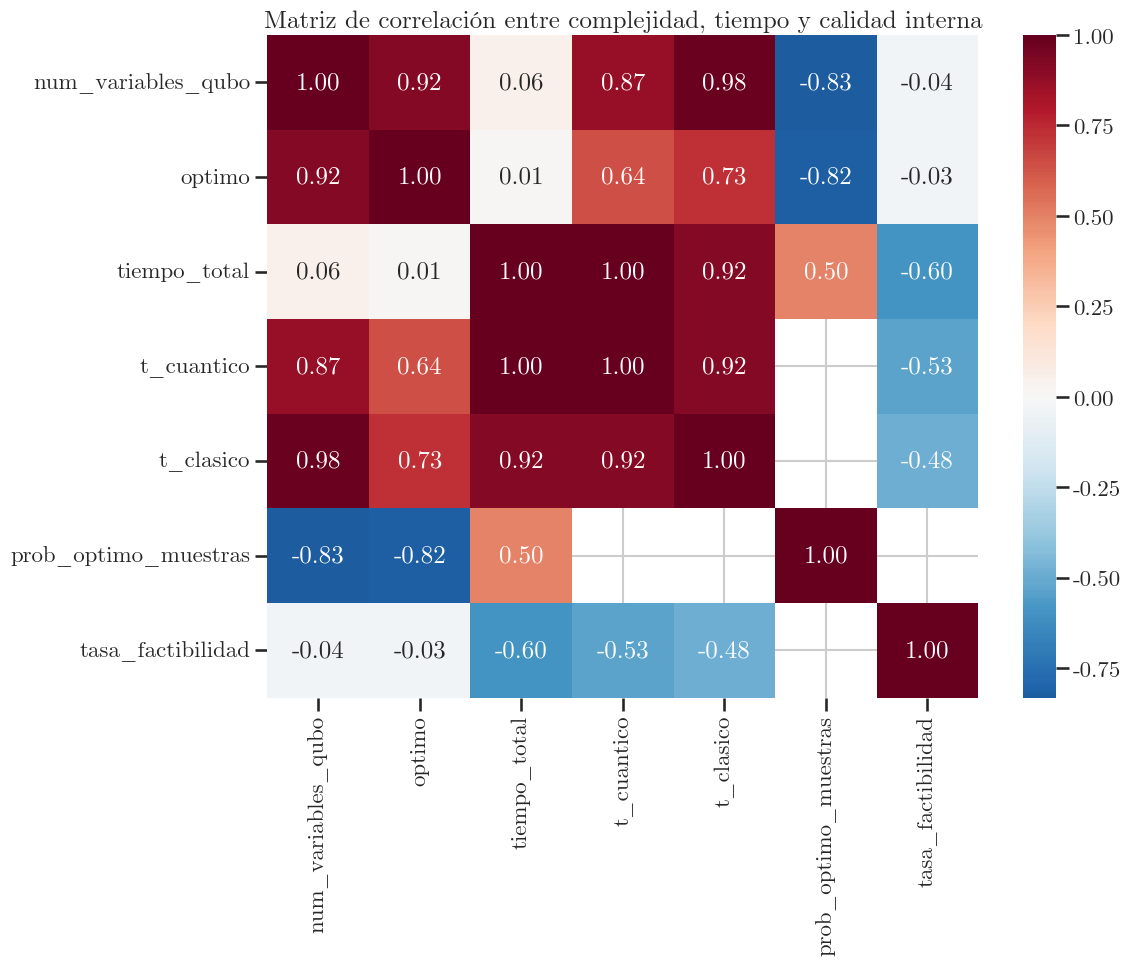

In [14]:
# Correlaciones entre complejidad y coste computacional
cols_corr = [
    'num_items', 'capacidad', 'num_variables_qubo', 'optimo',
    'tiempo_total', 't_solver', 't_cuantico', 't_clasico',
    'prob_optimo', 'ratio_optimo_medio', 'prob_optimo_muestras',
    'tasa_factibilidad', 'valor_medio_start'
]
cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlación entre complejidad, tiempo y calidad interna')
plt.tight_layout()
plt.savefig("figuras/matriz_correlacion_complejidad_tiempo_calidad.png", dpi=300, bbox_inches="tight")
plt.show()

ESTO HAY QUE ANALIZARLO CON LOS NUEVOS RESULTADOS.